<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/tema_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
# qr 
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


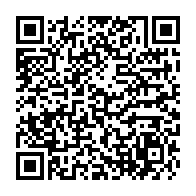

In [2]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/tema_4.ipynb")



In [1]:
import pandas as pd
import random

class SelectorEstudiantes:
    def __init__(self, ruta_archivo):
        self.ruta_archivo = ruta_archivo
        self.estudiantes_pendientes = self._cargar_estudiantes()

    def _cargar_estudiantes(self):
        try:
            # Leemos el archivo y preparamos la lista inicial
            df = pd.read_excel(self.ruta_archivo, sheet_name=0, skiprows=2)
            if 'NOMBRES Y APELLIDOS' not in df.columns:
                print("Error: No se encontró la columna 'NOMBRES Y APELLIDOS'.")
                return []
            
            lista = df['NOMBRES Y APELLIDOS'].dropna().tolist()
            # Mezclamos la lista de una vez para solo ir extrayendo
            random.shuffle(lista)
            return lista
        except Exception as e:
            print(f"Error al abrir el archivo: {e}")
            return []

    def elegir_proximo(self):
        if not self.estudiantes_pendientes:
            print("¡Todos los estudiantes han participado!")
            return None
        
        # .pop() saca el último elemento y lo elimina de la lista automáticamente
        estudiante = self.estudiantes_pendientes.pop()
        print(f"El estudiante seleccionado es: {estudiante}")
        return estudiante


In [2]:

# --- Ejemplo de uso ---
# 1. Instancias el selector (esto carga el Excel una sola vez)
caucasia = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia.xlsx"
bijao = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_bijao.xlsx"
selector = SelectorEstudiantes(bijao)


In [3]:

# 2. Llamas al método cada vez que necesites uno nuevo
selector.elegir_proximo()

El estudiante seleccionado es: GABRIELA BARRETO HERNÁNDEZ 


'GABRIELA BARRETO HERNÁNDEZ '

# Tema 4 Información Fundamentada en Procesos  

# Preguntas 1 y 2 

<img src = 'preguntas_1_y_2.jpeg' width = 1200>

# Método científico y control de variables  

Para resolver los problemas sobre el movimiento de péndulos (Imagen `preguntas_1_y_2.jpeg` de la sección "Información fundamentada en procesos"), aplicaremos el **Método Científico** y el control de variables.



### 1. Enunciado de los Problemas

En la figura se muestran cuatro péndulos ($A, B, C$ y $D$) con sus respectivas longitudes y pesos:
* **Péndulo A**: Longitud corta, peso de $6$ gr.
* **Péndulo B**: Longitud larga, peso de $4$ gr.
* **Péndulo C**: Longitud larga, peso de $6$ gr.
* **Péndulo D**: Longitud corta, peso de $12$ gr.


Este gráfico está diseñado de manera didáctica:
1.  **Visualización del Peso:** El tamaño (radio) de la masa azul es proporcional al peso en gramos ($4, 6, 12$).
2.  **Visualización de la Longitud:** La longitud de la línea negra representa la longitud relativa (corta vs larga).
3.  **Etiquetas Claras:** Cada péndulo incluye su nombre ($A, B, C, D$) y sus especificaciones técnicas.



# Script de Matplotlib: Generación de la Figura de Péndulos


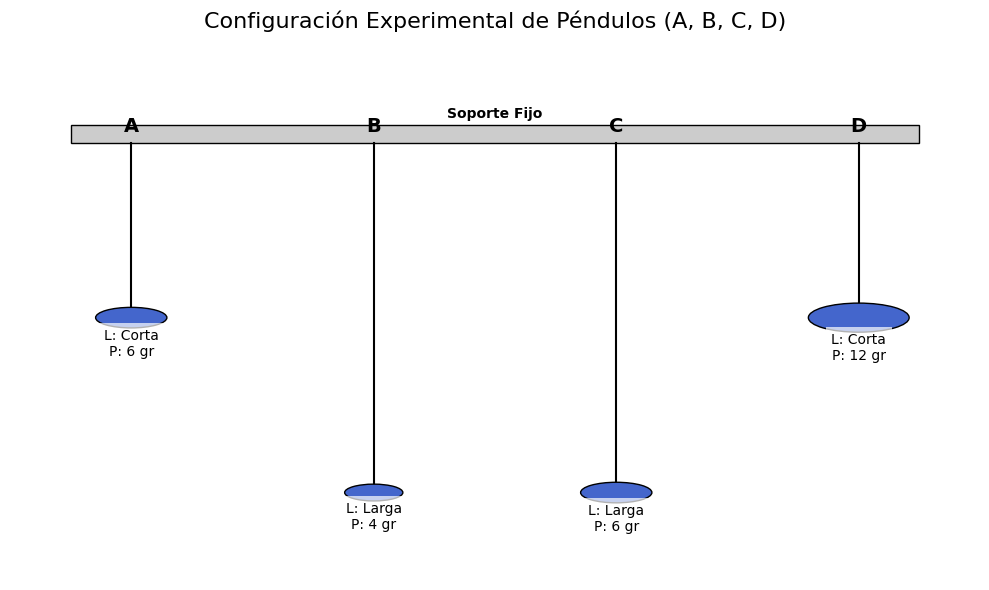

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. Definir los datos de los péndulos basados en el enunciado
# Estructura: 'Nombre': (Posición_X, Longitud_Visual, Peso_gr)
# Usamos longitudes relativas: Corta = 5, Larga = 10
datos_pendulos = {
    'A': (1, 5, 6),   # Corta, 6gr
    'B': (3, 10, 4),  # Larga, 4gr
    'C': (5, 10, 6),  # Larga, 6gr
    'D': (7, 5, 12)   # Corta, 12gr
}

# 2. Configurar el lienzo (Canvas)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 8)
ax.set_ylim(-1, 14) # Espacio para el soporte y las etiquetas superiores

# 3. Dibujar el soporte horizontal superior
soporte = patches.Rectangle((0.5, 11.5), 7, 0.5, linewidth=1, edgecolor='black', facecolor='#CCCCCC')
ax.add_patch(soporte)
ax.text(4, 12.2, "Soporte Fijo", ha='center', fontweight='bold')

# 4. Iterar sobre los datos para dibujar cada péndulo
for nombre, (x, L, P) in datos_pendulos.items():
    # Coordenadas
    y_soporte = 11.5
    y_masa = y_soporte - L
    
    # --- DIBUJAR CUERDA (Línea) ---
    ax.plot([x, x], [y_soporte, y_masa], color='black', lw=1.5, zorder=1)
    
    # --- DIBUJAR MASA (Círculo) ---
    # El radio de la masa es proporcional a la raíz cuadrada del peso
    # para que el ÁREA visual sea proporcional al peso real.
    radio_visual = np.sqrt(P) * 0.12 
    masa = patches.Circle((x, y_masa), radio_visual, linewidth=1, edgecolor='black', facecolor='#4466CC', zorder=2)
    ax.add_patch(masa)
    
    # --- AÑADIR ETIQUETAS DE DATOS ---
    # Nombre del Péndulo
    ax.text(x, y_soporte + 0.3, f"{nombre}", ha='center', fontsize=14, fontweight='bold', color='black')
    
    # Especificaciones técnicas debajo de la masa
    label_text = f"L: {'Corta' if L==5 else 'Larga'}\nP: {P} gr"
    ax.text(x, y_masa - (radio_visual + 0.8), label_text, ha='center', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# 5. Finalizar la estética del gráfico
plt.title("Configuración Experimental de Péndulos (A, B, C, D)", fontsize=16, pad=20)
plt.axis('off') # Ocultar ejes cartesianos para una vista limpia
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\pendulos_experimentales.png", dpi=300) # Guardar la figura como imagen de alta calidad
plt.show()


# Análisis Didáctico de la Figura Generada

Al ejecutar este código, obtendrás una imagen sintética que permite resolver las preguntas 4.1 y 4.2 instantáneamente mediante la observación:



* **Para el 4.1 (Cambiar Longitud, Mismo Peso):** Al mirar la figura, buscas dos masas del mismo tamaño (mismo peso) pero a diferente altura (diferente longitud). Verás que los péndulos **A** y **C** tienen el mismo tamaño de masa azul (ambos pesan $6$ gr) pero $A$ es corto y $C$ es largo. Esta es la combinación correcta.


* **Para el 4.2 (Cambiar Peso, Misma Longitud):** Buscas dos péndulos con la masa a la misma altura (misma longitud) pero de diferente tamaño (diferente peso). Verás que los péndulos **A** y **D** están a la misma altura (ambos son cortos), pero la masa de $D$ es notablemente más grande (pesa $12$ gr) que la de $A$ ($6$ gr). Esta es la combinación correcta.


#### **Problema 4.1**
Se quiere determinar si al cambiar la **longitud** de un péndulo cambia el tiempo que gasta en oscilar. ¿Qué péndulos deben utilizarse?

#### **Problema 4.2**
Se quiere saber si al cambiar el **peso** del péndulo cambia el tiempo que gasta en oscilar. ¿Qué péndulos deben utilizarse?

---



### 2. Estrategia de Resolución (< 2 minutos)

La clave es el **Control de Variables**: para medir el efecto de una variable (independiente), todas las demás deben permanecer constantes.

* **Para el 4.1 (Efecto de la Longitud):**
    1.  Variable que cambia: **Longitud**.
    2.  Variable constante: **Peso**.
    3.  Buscamos dos péndulos con mismo peso pero distinta longitud: **A ($6$ gr)** y **C ($6$ gr)**.
    * **Respuesta: (c) A y C.**



* **Para el 4.2 (Efecto del Peso):**
    1.  Variable que cambia: **Peso**.
    2.  Variable constante: **Longitud**.
    3.  Buscamos dos péndulos con misma longitud pero distinto peso: **A (corta, $6$ gr)** y **D (corta, $12$ gr)**.
    * **Respuesta: (a) A y D.**



### 3. Implementación Interactiva con Python

Utilizaremos **Matplotlib** para visualizar los péndulos y **ipywidgets** para experimentar con las variables.



In [5]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def simulador_pendulos(comparar):
    fig, ax = plt.subplots(figsize=(6, 7))
    ax.set_xlim(-1, 4)
    ax.set_ylim(0, 12)
    
    # Datos de los péndulos
    # (x, longitud, peso, nombre)
    pendulos = {
        'A': (0, 5, 6),
        'B': (1, 10, 4),
        'C': (2, 10, 6),
        'D': (3, 5, 12)
    }
    
    seleccionados = ['A', 'C'] if comparar == 'Longitud' else ['A', 'D']
    
    for nombre in seleccionados:
        x, L, P = pendulos[nombre]
        # Dibujar cuerda
        ax.plot([x, x], [12, 12-L], color='black', lw=1)
        # Dibujar masa (el tamaño depende del peso)
        ax.add_patch(plt.Circle((x, 12-L), P/10, color='blue'))
        ax.text(x, 12.5, f"Péndulo {nombre}\n{L} unidades\n{P} gr", ha='center')

    plt.title(f"Experimento para determinar efecto de la {comparar}")
    plt.axis('off')
    plt.savefig(r"C:\Users\marco\Downloads\simulador_pendulos_{comparar}.png", dpi=300) # Guardar la figura como imagen de alta calidad
    plt.show()

widgets.interact(simulador_pendulos, comparar=['Longitud', 'Peso'])


ModuleNotFoundError: No module named 'ipywidgets'


### 4. Fundamento Científico (SymPy)

Físicamente, el periodo de un péndulo simple $T$ está dado por la fórmula:

$$T \approx 2\pi \sqrt{\frac{L}{g}}$$

Donde:
* $L$ es la longitud del péndulo.
* $g$ es la aceleración de la gravedad.



Como se observa en la ecuación, **el periodo no depende de la masa ($m$)**. Por tanto, en el experimento 4.2 (A y D), el tiempo de oscilación debería ser el mismo a pesar de la diferencia de peso, mientras que en el 4.1 (A y C), el tiempo cambiará debido a la diferencia en $L$.



**Estrategia Maestra:**
1.  Identifica qué te piden medir.
2.  Busca los elementos que sean **idénticos en todo**, excepto en lo que te piden medir.

# Preguntas 3 y 4  



<img src = 'preguntas_3_y_4.jpeg' width = 1200>

# Análisis de **Ruta Crítica** y **dependencias de proyectos**.


Para resolver los retos de lógica y cronogramas presentados en la última imagen (`preguntas_3_y_4.jpeg`), aplicaremos un análisis de **Ruta Crítica** y **dependencias de proyectos**.



### 1. Enunciado del Problema (Preguntas 4.3 - 4.4)

El cronograma muestra las actividades programadas para solucionar problemas tras la inundación por la ruptura de un dique. Las duraciones iniciales son:
* **A (Instalación albergues):** Semanas 1 a 3 (3 semanas).
* **B (Reparación dique):** Semanas 1 a 10 (10 semanas).
* **C (Desagüe):** Semanas 4 a 11 (8 semanas). Inicia al cubrir el $30\%$ de B (semana 4).
* **D (Limpieza):** Semanas 8 a 13 (6 semanas). Inicia al cubrir el $50\%$ de C (semana 8).
* **E (Rehabilitación):** Semanas 10 a 14 (5 semanas). Inicia al cubrir el $20\%$ de D (semana 10).

---


In [6]:
# Tabla de doble entrada diseñada con pandas  
import pandas as pd

# 1. Definimos el rango de semanas
semanas = [str(i) for i in range(1, 15)]

# 2. Creamos un diccionario con los datos de la imagen
# 'X' representa la ejecución de la actividad en esa semana
cronograma_data = {
    'Actividades': [
        'A. Instalación de albergues',
        'B. Reparación del dique',
        'C. Desagüe de zonas inundadas',
        'D. Limpieza de zonas inundadas',
        'E. Rehabilitación de las tierras'
    ],
    '1':  ['X', 'X', '', '', ''],
    '2':  ['X', 'X', '', '', ''],
    '3':  ['X', 'X', '', '', ''],
    '4':  ['', 'X', 'X', '', ''],
    '5':  ['', 'X', 'X', '', ''],
    '6':  ['', 'X', 'X', '', ''],
    '7':  ['', 'X', 'X', 'X', ''],
    '8':  ['', 'X', 'X', 'X', ''],
    '9':  ['', 'X', 'X', 'X', 'X'],
    '10': ['', 'X', 'X', 'X', 'X'],
    '11': ['', 'X', 'X', 'X', 'X'],
    '12': ['', '', 'X', 'X', 'X'],
    '13': ['', '', '', 'X', 'X'],
    '14': ['', '', '', '', 'X']
}

# 3. Creamos el DataFrame
df = pd.DataFrame(cronograma_data)

# 4. Establecemos la actividad como índice para que se vea como una tabla de doble entrada
df.set_index('Actividades', inplace=True)

# 5. Visualización
print("Cronograma Inicial de Actividades (Semanas 1-14):")
df.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'center')])]
)

# Opcional: Exportar a Excel si lo necesitas
# df.to_excel("cronograma_emergencia.xlsx")

Cronograma Inicial de Actividades (Semanas 1-14):


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Actividades,,,,,,,,,,,,,,
A. Instalación de albergues,X,X,X,,,,,,,,,,,
B. Reparación del dique,X,X,X,X,X,X,X,X,X,X,X,,,
C. Desagüe de zonas inundadas,,,,X,X,X,X,X,X,X,X,X,,
D. Limpieza de zonas inundadas,,,,,,,X,X,X,X,X,X,X,
E. Rehabilitación de las tierras,,,,,,,,,X,X,X,X,X,X



### 2. Estrategia de Resolución (< 2 minutos)

La estrategia clave es identificar la **dependencia en cadena**. El fin de la obra total depende del fin de la actividad **E**, la cual depende del inicio de **D**, que depende de **C**, que depende de **B**.



#### **Resolución 4.3:**
Se informan demoras adicionales: A (+1), C (+2), E (+1).
1.  **A** no afecta el final porque termina mucho antes que las demás.
2.  **C** demora 2 semanas más. Como **D** inicia dependiendo del progreso de C, el final de C se desplaza, pero lo vital es que si C se alarga, empuja el inicio de D y consecuentemente el de E.
3.  Si C se atrasa 2 semanas y E se atrasa 1 semana, el retraso total acumulado en la cadena final es $2 + 1 = 3$ semanas.
* **Respuesta: (b) 3 semanas más.**



#### **Resolución 4.4:**
Cambios: A (-1), B (+2), C (+2), D (0), E (-2).
1.  **B** tarda 2 semanas más $\rightarrow$ C inicia 2 semanas tarde.
2.  **C** tarda 2 semanas más $\rightarrow$ D inicia 2 semanas tarde (acumulado 4 semanas de retraso para el inicio de D).
3.  **D** se cumple según lo programado (su duración no cambia), pero inicia 4 semanas tarde $\rightarrow$ E inicia 4 semanas tarde.
4.  **E** requiere 2 semanas menos de duración. Si inicia 4 semanas tarde pero dura 2 menos: $+4 - 2 = +2$ semanas.
* **Respuesta: (c) Demoró dos semanas más.**

---



### 3. Modelado y Visualización con Python

Utilizaremos **Pandas** para estructurar los datos y **Matplotlib** para visualizar el Diagrama de Gantt original vs. el modificado.



Diagrama de Gantt Original


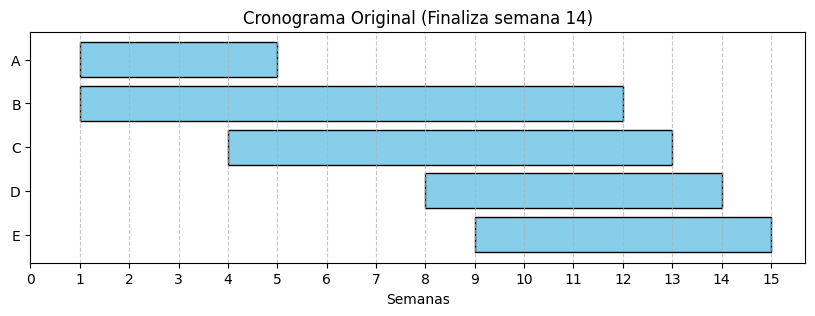

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos iniciales
df = pd.DataFrame({
    'Actividad': ['A', 'B', 'C', 'D', 'E'],
    'Inicio': [1, 1, 4, 8, 9],
    'Duracion': [4, 11, 9, 6, 6]
})

def plot_gantt(data, title):
    fig, ax = plt.subplots(figsize=(10, 3))
    for i, row in data.iterrows():
        ax.barh(row['Actividad'], row['Duracion'], left=row['Inicio'], color='skyblue', edgecolor='black')
    ax.set_xlabel('Semanas')
    ax.set_title(title)
    ax.invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.xticks(range(0, 16))  # Ajustar las marcas del eje x para mostrar semanas completas
    plt.savefig(r"C:\Users\marco\Downloads\gantt_original.png", dpi=300)  # Guardar la figura como imagen
    plt.show()

print("Diagrama de Gantt Original")
plot_gantt(df, "Cronograma Original (Finaliza semana 14)")


### 4. Simulación Interactiva (ipywidgets)

Este componente permite ver cómo el retraso de una actividad temprana "empuja" a las demás.


In [2]:
import ipywidgets as widgets

def simular_obra(atraso_B, atraso_C, ahorro_E):
    fin_B = 10 + atraso_B
    inicio_C = 4 + (atraso_B) # Dependencia simplificada
    fin_C = inicio_C + 8 + atraso_C
    inicio_D = 8 + (atraso_B + atraso_C)
    fin_D = inicio_D + 6
    inicio_E = 10 + (atraso_B + atraso_C)
    fin_total = inicio_E + 5 - ahorro_E
    
    retraso_total = fin_total - 14
    print(f"La obra finaliza en la semana: {fin_total}")
    print(f"Retraso respecto al plan original: {retraso_total} semanas")

widgets.interact(simular_obra, atraso_B=(0,5,1), atraso_C=(0,5,1), ahorro_E=(0,5,1))


interactive(children=(IntSlider(value=2, description='atraso_B', max=5), IntSlider(value=2, description='atras…

<function __main__.simular_obra(atraso_B, atraso_C, ahorro_E)>

### Estrategia Maestra para Exámenes
1.  **Identifica el "Finalizador":** En este caso es E. Todo lo que afecte la duración o el inicio de E afecta el total.
2.  **Suma y Resta de Deltas:** No recalculas todo el calendario; simplemente sumas los retrasos ($+$) y restas los ahorros ($-$) de las actividades en la ruta crítica.
3.  **Ignora el "Ruido":** La actividad A termina en la semana 3. Cualquier cambio en ella (mientras no supere el fin de la obra) es irrelevante para el tiempo total.

# Preguntas 5 a 7 

<img src = 'preguntas_5_a_7.jpeg' width = 1200>

Para resolver los retos de interpretación de gráficas distancia-tiempo (Imagen `preguntas_5_a_7.jpeg`), aplicaremos conceptos de cinemática básica y análisis de funciones lineales. El objetivo es relacionar el movimiento físico (acercarse, alejarse o estar quieto) con la pendiente y los puntos de corte de cada recta.

---

### 1. Enunciado y Reglas de Interpretación
Las gráficas muestran la distancia de dos personas $P$ y $Q$ respecto a un museo a través del tiempo.
* **Hacia el museo:** La distancia disminuye (pendiente negativa). El eje horizontal (tiempo) representa la llegada (distancia $= 0$).
* **Desde el museo:** La distancia aumenta (pendiente positiva).
* **Parado:** La distancia es constante (pendiente cero, línea horizontal).



Este código está diseñado para ser altamente didáctico y recrear fielmente las características visuales y lógicas de la imagen original:
1.  **Matriz de 1x4:** Se crea una fila con cuatro subgráficos.
2.  **Etiquetas Claras:** Ejes etiquetados como "Tiempo" y "Distancia".
3.  **Lógica del Movimiento:** Cada recta representa la ecuación de distancia-tiempo, $d(t) = d_0 + v \cdot t$, donde una pendiente negativa indica acercarse al museo y una horizontal indica estar quieto.
4.  **Estilo:** Colores y leyendas diferenciadas para las personas $P$ y $Q$.



# Script de Matplotlib: Generación de las Gráficas Distancia-Tiempo


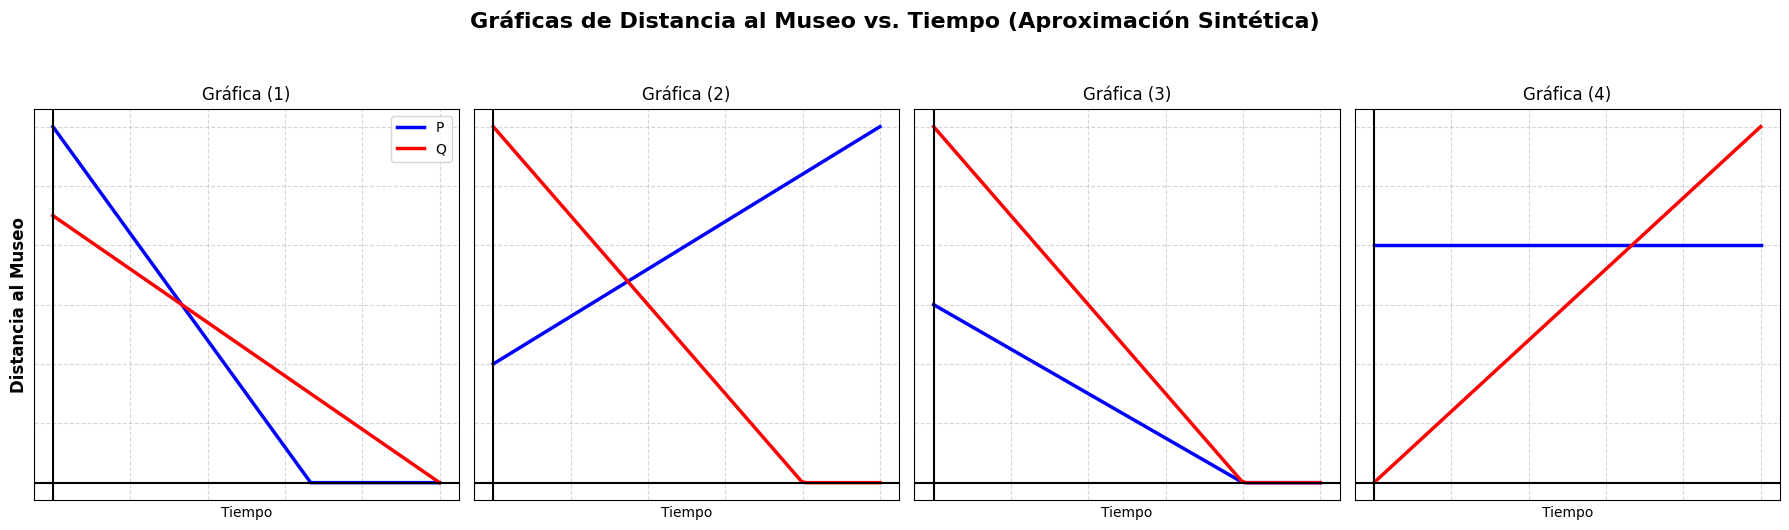

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurar el lienzo (Canvas) para una matriz de 1x4
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
fig.suptitle("Gráficas de Distancia al Museo vs. Tiempo (Aproximación Sintética)", fontsize=16, fontweight='bold', y=1.05)

# Definir el rango de tiempo (eje horizontal)
t = np.linspace(0, 10, 100)

# ==========================================
# GRÁFICA (1)
# Planteamiento: P y Q hacia el museo, P más lejos pero llegó primero.
# ==========================================
ax1 = axes[0]
d0_p1, v_p1 = 12, -1.8  # Inicia alto, pendiente fuerte (llega en t=6.6)
d0_q1, v_q1 = 9, -0.9   # Inicia más bajo, pendiente suave (llega en t=10)
dp1 = np.maximum(0, d0_p1 + v_p1 * t)
dq1 = np.maximum(0, d0_q1 + v_q1 * t)

ax1.plot(t, dp1, label='P', color='blue', lw=2.5)
ax1.plot(t, dq1, label='Q', color='red', lw=2.5)
ax1.set_title("Gráfica (1)")
ax1.legend()

# ==========================================
# GRÁFICA (2)
# Planteamiento: P se aleja, Q se acerca (o se cruzan).
# ==========================================
ax2 = axes[1]
d0_p2, v_p2 = 4, 0.8    # Inicia bajo, se aleja
d0_q2, v_q2 = 12, -1.5  # Inicia alto, se acerca rápido (llega en t=8)
dp2 = d0_p2 + v_p2 * t
dq2 = np.maximum(0, d0_q2 + v_q2 * t)

ax2.plot(t, dp2, label='P', color='blue', lw=2.5)
ax2.plot(t, dq2, label='Q', color='red', lw=2.5)
ax2.set_title("Gráfica (2)")
# ax2.legend() # Opcional, ya está en la primera

# ==========================================
# GRÁFICA (3)
# Planteamiento: Mismo tiempo de llegada, Q más lejos.
# ==========================================
ax3 = axes[2]
d0_p3, v_p3 = 6, -0.75  # Llega en t=8
d0_q3, v_q3 = 12, -1.5  # Llega en t=8 (más lejos, más rápido)
dp3 = np.maximum(0, d0_p3 + v_p3 * t)
dq3 = np.maximum(0, d0_q3 + v_q3 * t)

ax3.plot(t, dp3, label='P', color='blue', lw=2.5)
ax3.plot(t, dq3, label='Q', color='red', lw=2.5)
ax3.set_title("Gráfica (3)")

# ==========================================
# GRÁFICA (4)
# Planteamiento: P parada, Q se aleja del museo y se cruzan.
# ==========================================
ax4 = axes[3]
d0_p4, v_p4 = 8, 0      # Parada a distancia constante
d0_q4, v_q4 = 0, 1.2    # Sale del museo (d=0) y se aleja
dp4 = np.full_like(t, d0_p4)
dq4 = d0_q4 + v_q4 * t

ax4.plot(t, dp4, label='P', color='blue', lw=2.5)
ax4.plot(t, dq4, label='Q', color='red', lw=2.5)
ax4.set_title("Gráfica (4)")

# --- Configuración estética global de los ejes ---
for ax in axes:
    ax.set_xlabel("Tiempo")
    ax.grid(True, linestyle='--', alpha=0.5)
    # Recrear el estilo visual de la imagen: Ejes negros gruesos que se cruzan en el origen
    ax.axhline(0, color='black', lw=1.5) # Eje horizontal (Museo d=0)
    ax.axvline(0, color='black', lw=1.5) # Eje vertical (Tiempo 0)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False) # Ocultar números para vista abstracta
    
# Solo etiquetar el primer eje vertical
axes[0].set_ylabel("Distancia al Museo", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\p_y_q.png")
plt.show()


### Análisis Didáctico de la Figura

Al ejecutar el script, obtendrás una figura sintética que te permitirá visualizar y validar instantáneamente las respuestas a las preguntas 4.5, 4.6 y 4.7 mediante la observación de los puntos de corte y las pendientes:

* **Para el 4.5:** En la **Gráfica (1)**, puedes ver que la recta **$P$ (azul)** comienza más arriba en el eje de distancia (estaba más lejos) y toca el eje de tiempo a la izquierda de donde lo hace la recta **$Q$ (roja)** (llegó primero).
* **Para el 4.6:** En la **Gráfica (4)**, la recta **$P$ (azul)** es una línea horizontal (está quieta), mientras que la recta **$Q$ (roja)** sube desde el punto $0$ (viene del museo).
* **Para el 4.7:** En la **Gráfica (3)**, ambas rectas, $P$ y $Q$, se unen exactamente en el mismo punto final sobre el eje de tiempo (tardaron el mismo tiempo en llegar), pero la recta **$Q$ (roja)** arranca desde una distancia inicial mayor.


### 2. Resolución Estratégica (< 2 minutos)



#### **Problema 4.5: $P$ y $Q$ caminan hacia el museo, $P$ estaba más lejos y llegó primero.**
1.  **Hacia el museo:** Ambas deben bajar hasta tocar el eje del tiempo.
2.  **$P$ más lejos:** En el tiempo $0$, la línea $P$ debe iniciar más arriba que $Q$.
3.  **$P$ llegó primero:** La línea $P$ debe tocar el eje horizontal a la izquierda de donde lo hace $Q$.
* **Análisis:** En la gráfica **(1)**, $P$ inicia arriba de $Q$ (estaba más lejos) y cruza el eje antes que $Q$ (llegó primero).
* **Respuesta: (a) (1)**.

#### **Problema 4.6: $P$ parada y se encuentra con $Q$ que venía del museo.**
1.  **$P$ parada:** Línea horizontal para $P$.
2.  **$Q$ venía del museo:** La distancia de $Q$ aumenta (pendiente positiva).
3.  **Se encuentran:** Las líneas deben cruzarse.
* **Análisis:** En la gráfica **(4)**, $P$ es horizontal y $Q$ sube desde el origen (museo) hasta cruzarse con $P$.
* **Respuesta: (d) (4)**.

#### **Problema 4.7: $P$ y $Q$ tardaron el mismo tiempo, aunque $Q$ estaba más lejos.**
1.  **Mismo tiempo en llegar:** Ambas deben tocar el eje del tiempo exactamente en el mismo punto.
2.  **$Q$ más lejos:** En el tiempo $0$, la línea $Q$ debe iniciar más arriba que $P$.
* **Análisis:** En la gráfica **(3)**, ambas rectas convergen al mismo punto final en el eje del tiempo, pero $Q$ arranca desde un punto más alto.
* **Respuesta: (c) (3)**.

---

### 3. Simulación Interactiva con Python

Utilizaremos **Matplotlib** y **ipywidgets** para recrear estas gráficas dinámicamente y entender el impacto de la velocidad ($v$) y la posición inicial ($d_0$).

$$d(t) = d_0 + v \cdot t$$




In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

def graficar_movimiento(p_dist, p_vel, q_dist, q_vel):
    t = np.linspace(0, 10, 100)
    # Ecuación de distancia: d = d0 + v*t
    # v es negativa si se acercan al museo
    dp = np.maximum(0, p_dist + p_vel * t)
    dq = np.maximum(0, q_dist + q_vel * t)
    
    plt.figure(figsize=(8, 5))
    plt.plot(t, dp, label='Persona P', color='blue', lw=2)
    plt.plot(t, dq, label='Persona Q', color='red', lw=2)
    
    plt.axhline(0, color='black', lw=1) # El Museo (Distancia 0)
    plt.ylim(-1, 15)
    plt.xlabel('Tiempo')
    plt.ylabel('Distancia al Museo')
    plt.title('Simulador de Gráficas de Movimiento')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(r"C:\Users\marco\Downloads\simulador_p_y_q.png", dpi=300) # Guardar la figura como imagen de alta calidad
    plt.show()

# Configuración para imitar la gráfica (1)
widgets.interact(graficar_movimiento, 
    p_dist=(0, 15, 1), p_vel=(-2, 2, 0.5), 
    q_dist=(0, 15, 1), q_vel=(-2, 2, 0.5)
)


interactive(children=(IntSlider(value=7, description='p_dist', max=15), FloatSlider(value=0.0, description='p_…

<function __main__.graficar_movimiento(p_dist, p_vel, q_dist, q_vel)>

### 4. Estrategia Maestra para Exámenes
* **Punto de llegada:** Fíjate siempre dónde termina la línea en el eje $X$. Si terminan juntas, llegaron al mismo tiempo.
* **Punto de partida:** Mira el eje $Y$ (distancia inicial). La que esté más arriba estaba más lejos.
* **Velocidad:** La "inclinación" (pendiente) te dice quién va más rápido. En la gráfica (3), $Q$ tiene una pendiente más pronunciada porque debe recorrer más distancia en el mismo tiempo.

# Preguntas 8 a 10

<img src = 'pregunta_8.jpeg' width = 1200>

Para resolver este reto de lógica de circuitos y condicionales (Imagen `pregunta_8.jpeg`), aplicaremos un enfoque de **Lógica Proposicional** y **Dependencia en Cascada**. El objetivo es identificar la única afirmación verdadera basándonos en la jerarquía del sistema eléctrico descrito.

---



### 1. Enunciado del Problema (Pregunta 4.8)

**Contexto:** Se tiene una fuente principal y dos extensiones idénticas, **A** y **B**, cada una con 3 conexiones (1, 2, 3) y un interruptor ON/OFF.
* **Regla 1:** La extensión **A** se conecta a la fuente principal. Para que sus conexiones funcionen, debe haber corriente en la fuente y el interruptor de A debe estar en **ON**.
* **Regla 2:** La extensión **B** se conecta a la **conexión 3 de la extensión A**. Para que sus conexiones funcionen, la conexión 3 de A debe estar activa y el interruptor de B debe estar en **ON**.

**Reto:** Determinar cuál de las proposiciones es la única verdadera.

---



### 2. Estrategia de Resolución (< 2 minutos)

Utilizamos el concepto de **Condición Necesaria vs. Condición Suficiente**:

1.  **Analizar la dependencia:** Para que **B** tenga energía, **necesariamente** la conexión 3 de **A** debe estar activa. Sin embargo, que la conexión 3 de **A** esté activa no garantiza que **B** funcione (porque el interruptor de B podría estar en OFF).
2.  **Evaluación de opciones:**
    * **(a)** Falsa. Si la conexión 3 de A está activa, B solo funcionará si su propio interruptor está en ON.
    * **(b)** Falsa. Que B no esté activada no implica nada sobre A; A podría estar funcionando perfectamente y el problema ser solo el interruptor de B.
    * **(c)** Falsa. Similar a la anterior; que B no tenga energía no significa que la fuente principal esté fallando.
    * **(d) VERDADERA:** Si la conexión 3 de **B** está activa, significa que la energía logró pasar por toda la cadena anterior. Por lo tanto, **necesariamente** la conexión 3 de **A** tuvo que estar activada para suministrarle corriente a B.

**Respuesta Correcta: (d)**.

---



### 3. Implementación Interactiva y Didáctica

Utilizaremos **ipywidgets** para crear un simulador de flujo de corriente. Esto permite experimentar con los interruptores y observar cómo la energía depende de la jerarquía.



In [10]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def simulador_energia(fuente, switch_A, switch_B):
    # Lógica de cascada
    A_activa = fuente and switch_A
    B_activa = A_activa and switch_B
    
    # Visualización
    print(f"ESTADO DEL SISTEMA:")
    print(f"{'🟢' if fuente else '🔴'} Fuente Principal")
    print(f"{'🟢' if A_activa else '🔴'} Conexión 3 de Extensión A")
    print(f"{'🟢' if B_activa else '🔴'} Conexión 3 de Extensión B")
    
    if B_activa:
        print("\n✅ CONCLUSIÓN: Si B está activa, A DEBIÓ estar activa.")

# Interfaz interactiva
widgets.interact(simulador_energia, 
                 fuente=widgets.Checkbox(value=True, description='Fuente AC'),
                 switch_A=widgets.Checkbox(value=True, description='Switch A (ON)'),
                 switch_B=widgets.Checkbox(value=False, description='Switch B (ON)'))


ModuleNotFoundError: No module named 'ipywidgets'

### 4. Demostración Lógica con SymPy

Podemos expresar esto mediante implicaciones lógicas:

Sea $A$ el estado de la conexión 3 de la extensión A, y $B$ el estado de la conexión 3 de la extensión B.
La regla fundamental es:
$$B \implies A$$

Esto significa que $A$ es una **condición necesaria** para $B$. En lógica proposicional, si el consecuente de una cadena es verdadero, todos los eslabones necesarios anteriores deben ser verdaderos.

**Estrategia Maestra:**
Cuando veas sistemas en serie o "cascada", siempre lee de **atrás hacia adelante**. El estado del último elemento te da información segura sobre todos los anteriores, pero el estado de los primeros no te asegura nada sobre los últimos.

# Preguntas 9 y 10 

<img src = 'preguntas_9_y_10.jpeg' width = 1200>

Para resolver los problemas 4.9 y 4.10 de la imagen `preguntas_9_y_10.jpeg`, es fundamental recordar la arquitectura del sistema eléctrico presentada en el problema 4.8:
1.  **Fuente Principal** $\rightarrow$ **Extensión A** (Interruptor A y 3 conexiones).
2.  **Conexión 3 de A** $\rightarrow$ **Extensión B** (Interruptor B y 3 conexiones).

---



### 1. Enunciado y Resolución Didáctica (< 2 minutos)

#### **Problema 4.9: Tres aparatos funcionando (2 lámparas y 1 TV)**
**Premisa:** Los tres aparatos funcionan. Esto significa que a los tres les llega energía.
* **Estrategia:** Si al menos un aparato funciona, la **Extensión A** debe estar obligatoriamente en **ON** y conectada a la fuente, ya que es la puerta de entrada de energía para todo el sistema.
* **Análisis de opciones:** No podemos asegurar que la Extensión B esté en ON (los 3 aparatos podrían estar en A), ni que alguno esté en B. Pero sí es una **certeza absoluta** que A debe estar encendida.

**Respuesta Correcta: (b) La extensión A tiene activada su posición ON.**



#### **Problema 4.10: Dos electrodomésticos, uno con corriente y otro no**
**Premisa:** Dos aparatos en buen estado, uno recibe corriente y el otro no. Las extensiones están en buen estado.
* **Estrategia:** Buscamos la opción que **no concuerda lógicamente** (la contradicción).
* **Análisis de la opción (d):** Dice que "sólo un cable está conectado y la posición de su extensión está en OFF". Si la extensión está en OFF, **ninguno** de los dos aparatos podría recibir corriente. Esto contradice la premisa de que a uno sí le llega corriente.

**Respuesta Correcta: (d)**

---



### 2. Modelado Lógico con SymPy y Python

Podemos representar la disponibilidad de energía como una función booleana de cascada.



In [14]:
import ipywidgets as widgets
from IPython.display import display

def verificar_logica(pos_A, pos_B, conecta_B_en_A):
    # Energía en conexiones de A
    energia_A = pos_A == 'ON'
    # Energía en conexiones de B (depende de A y de su propio switch)
    energia_B = energia_A and conecta_B_en_A and (pos_B == 'ON')
    
    print(f"--- ESTADO DE LAS CONEXIONES ---")
    print(f"Conexiones 1,2,3 de A: {'⚡ ACTIVA' if energia_A else '❌ APAGADA'}")
    print(f"Conexiones 1,2,3 de B: {'⚡ ACTIVA' if energia_B else '❌ APAGADA'}")

# Selector interactivo para experimentar la cascada
widgets.interact(verificar_logica, 
    pos_A=['ON', 'OFF'], 
    pos_B=['ON', 'OFF'], 
    conecta_B_en_A=widgets.Checkbox(value=True, description='B conectada a A'))


interactive(children=(Dropdown(description='pos_A', options=('ON', 'OFF'), value='ON'), Dropdown(description='…

<function __main__.verificar_logica(pos_A, pos_B, conecta_B_en_A)>

### 3. Representación Matemática

Sea $E_A$ la energía en la Extensión A y $E_B$ en la Extensión B. Definimos las variables de control $S_A, S_B \in \{0, 1\}$ (Interruptores) y $C_{BA} \in \{0, 1\}$ (Conexión física de B en A):

$$E_A = S_A$$
$$E_B = E_A \cdot C_{BA} \cdot S_B = S_A \cdot C_{BA} \cdot S_B$$

En el **Problema 4.10**, si un aparato tiene corriente, existe al menos una conexión con energía ($E_A=1$ o $E_B=1$). Ambas condiciones implican necesariamente que $S_A = 1$. Por tanto, la afirmación de que la posición de la extensión está en OFF ($S=0$) es lógicamente imposible.

Esta clase continúa el desarrollo del razonamiento cuantitativo y se centra en **probabilidad, análisis de casos y razonamiento estadístico**, que aparecen con frecuencia en la prueba.



# Clase 4

# Probabilidad y análisis de casos

Duración: **3 horas**

---



# Objetivos de la clase

Al finalizar la sesión el estudiante podrá:

* aplicar el concepto de probabilidad clásica
* analizar eventos simples y compuestos
* resolver problemas de probabilidad del examen en **menos de 3 minutos**
* verificar resultados mediante **simulación en Python**

---



# Concepto fundamental

La probabilidad clásica se define como

$$
P(A)=\frac{\text{casos favorables}}{\text{casos posibles}}
$$




# Estrategia clave del examen

1. **Contar los casos posibles**
2. **Contar los casos favorables**
3. Aplicar la fórmula de probabilidad.

---



# PARTE I

# 12 problemas tomados de la prueba diagnóstica

---

# Problema 1 (bolitas de chicle)

Anita tiene:

3 rojas
2 azules

Se extraen **3 bolas**.

¿Cuál es la probabilidad de obtener **exactamente dos rojas**?

---



## Estrategia

Número total de combinaciones:

$$
\binom{5}{3}=10
$$



Casos favorables:

Elegir 2 rojas de 3:

$
\binom{3}{2}
$

Elegir 1 azul de 2:

$
\binom{2}{1}
$



Total:

$$
3 \times 2 =6
$$



## Probabilidad

$$
P=\frac{6}{10}=0.6
$$




## Python


In [11]:
import math

total = math.comb(5,3)

favorables = math.comb(3,2) * math.comb(2,1)

favorables/total


0.6

# Problema 2 (dados)

Se lanza un dado.

Probabilidad de obtener número **par**.

---

## Estrategia

Casos posibles: $6$

Favorables: $2,4,6$

---



$
P=\frac{3}{6}=\frac{1}{2}
$

---



## Python

```python
pares=[2,4,6]

len(pares)/6
```

---



# Problema 3 (dos dados)

Probabilidad de que la suma sea **7**.

---

## Estrategia

Casos posibles:

$
6\times6=36
$

Casos favorables:

$(1,6),(2,5),(3,4),(4,3),(5,2),(6,1)$

Total $6$.

---



$
P=\frac{6}{36}=\frac{1}{6}
$

---

## Python

```python
import itertools

dados=list(itertools.product(range(1,7),repeat=2))

favorables=[d for d in dados if sum(d)==7]

len(favorables)/len(dados)
```

---

# Problema 4 (números de dos cifras)

Elegir un número de dos cifras al azar.

Probabilidad de que ambas cifras sean iguales.

---

## Estrategia

Números posibles:

$
90
$

Casos favorables:

$
11,22,...,99
$

Total $9$.

---

$
P=\frac{9}{90}=0.1
$

---

## Python

```python
nums=list(range(10,100))

favorables=[n for n in nums if str(n)[0]==str(n)[1]]

len(favorables)/len(nums)
```

---

# Problema 5 (monedas)

Se lanzan **3 monedas**.

Probabilidad de obtener **exactamente dos caras**.

---

## Estrategia

Casos posibles:

$
2^3=8
$

Casos favorables:

$
\binom{3}{2}=3
$

---

$
P=\frac{3}{8}
$

---

## Python

```python
import itertools

monedas=list(itertools.product(["C","S"],repeat=3))

favorables=[m for m in monedas if m.count("C")==2]

len(favorables)/len(monedas)
```

---

# Problema 6 (cartas)

Se elige una carta de un mazo.

Probabilidad de que sea **corazón**.

---

## Estrategia

Cartas totales:

$
52
$

Corazones:

$
13
$

---

$
P=\frac{13}{52}=\frac{1}{4}
$

---

# Problema 7 (delegación deportiva)

Elegir un deportista al azar.

Probabilidad de que sea **atleta**.

---

$
P=\frac{64}{200}=0.32
$

---

## Python

```python
64/200
```

---

# Problema 8 (números pares)

Elegir un número de tres cifras.

Probabilidad de que sea par.

---

Casos posibles:

$
900
$

Casos favorables:

$
450
$

---

$
P=\frac{450}{900}=\frac{1}{2}
$

---

## Python

```python
pares=[n for n in range(100,1000) if n%2==0]

len(pares)/900
```

---

# Problema 9 (dados)

Probabilidad de obtener número mayor que $4$.

---

Favorables:

$
5,6
$

---

$
P=\frac{2}{6}=\frac{1}{3}
$

---

# Problema 10 (personas)

Elegir una persona al azar.

Probabilidad de elegir mujer.

---

$
P=\frac{90}{200}=0.45
$

---

# Problema 11 (subconjuntos)

Elegir subconjunto al azar de un conjunto de 4 elementos.

Probabilidad de elegir uno con **exactamente 2 elementos**.

---

Casos posibles:

$
2^4=16
$

Favorables:

$
\binom{4}{2}=6
$

---

$
P=\frac{6}{16}
$

---

# Problema 12 (anagramas)

Elegir al azar un anagrama de "CASA".

Probabilidad de obtener uno que empiece con **C**.

---

Total anagramas:

$
\frac{4!}{2!}=12
$

Favorables:

$
3!=6
$

---

$
P=\frac{6}{12}=\frac{1}{2}
$

---

# PARTE II

# 12 ejercicios similares

---

# Problema 13

Probabilidad de obtener **cara** al lanzar moneda.

$

P=\frac{1}{2}

$

---

# Problema 14

Probabilidad de obtener número primo al lanzar dado.

Primos:

$
2,3,5
$

---

$
P=\frac{3}{6}
$

---

# Problema 15

Probabilidad de elegir número múltiplo de $5$ entre $1$ y $100$.

---

Favorables:

$
20
$

---

$
P=\frac{20}{100}
$

---

# Problema 16

Probabilidad de obtener al menos una cara al lanzar dos monedas.

---

$
P=1-\frac{1}{4}=\frac{3}{4}
$

---

## Python

```python


In [3]:
import itertools

mon=list(itertools.product(["C","S"],repeat=2))

favorables=[m for m in mon if "C" in m]

len(favorables)/len(mon)


0.75


# Problema 17

Probabilidad de obtener suma $8$ con dos dados.

---

Casos favorables:

$(2,6),(3,5),(4,4),(5,3),(6,2)$

---

$
P=\frac{5}{36}
$

---

# Problema 18

Probabilidad de elegir número divisible por $3$ entre $1$ y $30$.

---

$
10/30
$

---

# Problema 19

Probabilidad de elegir vocal en la palabra **CASA**.

---

$
2/4
$

---

# Problema 20

Probabilidad de obtener número mayor que $7$ al lanzar dos dados.

---

Simulación Python:



In [4]:
import itertools 
dados=list(itertools.product(range(1,7),repeat=2))

fav=[d for d in dados if sum(d)>7]

len(fav)/len(dados)


0.4166666666666667


# Problema 21

Se tiene un **mazo estándar de cartas** de baraja inglesa.

Este mazo contiene **52 cartas** distribuidas en **4 palos**:

* corazones ♥
* diamantes ♦
* tréboles ♣
* picas ♠

Cada palo tiene **13 cartas**.

Se elige **una carta al azar**.

**Pregunta**

¿Cuál es la probabilidad de que la carta elegida sea **roja**?
<img src = 'corazones_diamantes_treboles_picas.png'>



# Paso 1: Identificar el espacio muestral

El **espacio muestral** es el conjunto de todos los resultados posibles.

En este caso:

$
|S| = 52
$

porque el mazo tiene **52 cartas**.

---



# Paso 2: Identificar los casos favorables

Las cartas **rojas** son las de los palos:

* corazones
* diamantes

Cada palo tiene:

$
13
$

cartas.

Entonces el número total de cartas rojas es

$
13 + 13 = 26
$

---



# Paso 3: Aplicar la fórmula de probabilidad

La probabilidad clásica es

$
P(A)=\frac{\text{casos favorables}}{\text{casos posibles}}
$



Sustituyendo:

$
P(\text{carta roja})=\frac{26}{52}
$

---



# Paso 4: Simplificar la fracción

Dividimos numerador y denominador entre $26$:

$
P=\frac{26}{52}=\frac{1}{2}
$

---



# Interpretación

La probabilidad es

$
P=0.5
$

lo que significa que **la mitad de las cartas del mazo son rojas**.

---



# Verificación con Python

Podemos representar el mazo y contar las cartas rojas.



In [5]:
palos = ["corazon","diamante","trebol","pica"]

mazo = []

for palo in palos:
    for carta in range(1,14):
        mazo.append((palo,carta))

rojas = [c for c in mazo if c[0] in ["corazon","diamante"]]

len(rojas)/len(mazo)


0.5

Resultado esperado:

```
0.5
```

---



# Visualización con Python

Podemos representar la proporción de cartas.

```python


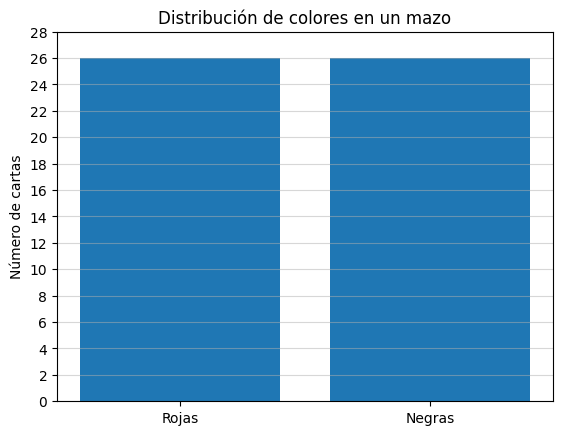

In [10]:
import matplotlib.pyplot as plt

categorias = ["Rojas","Negras"]
valores = [26,26]

plt.bar(categorias,valores)
plt.ylabel("Número de cartas")
plt.title("Distribución de colores en un mazo")
plt.yticks(range(0,30,2))
plt.grid(alpha=0.5, axis='y')
plt.savefig(r"C:\Users\marco\Downloads\distribucion_cartas.png")

plt.show()


Esto ayuda a los estudiantes a **visualizar que la mitad del mazo es rojo y la otra mitad negro**.

---

# Estrategia rápida para el examen

Cuando el problema menciona **cartas rojas en una baraja estándar**, recordar inmediatamente:

* cartas rojas = **26**
* total cartas = **52**

Por lo tanto

$
P = \frac{1}{2}
$

Se puede responder en **menos de 10 segundos**.

---



# Problema 22

Probabilidad de elegir número impar entre $1$ y $20$.

---

$
10/20
$

---



# Problema 23

Probabilidad de elegir subconjunto vacío de conjunto de 3 elementos.

---

$
1/8
$

---



# Problema 24

Probabilidad de obtener exactamente **una cara** al lanzar dos monedas.

---



$$
\binom{2}{1}/4 = 2/4
$$

---



# Actividad final

Resolver **8 preguntas tipo examen en 15 minutos**.


# Resultado esperado

Después de la clase se espera que puedan:

* analizar eventos probabilísticos
* contar casos favorables y posibles
* resolver problemas del examen en **menos de 3 minutos**
* verificar soluciones mediante **simulación con Python**
